In [106]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

DATA  = "../data/attention_over_time_seed2.npz"
SIGMA = 50
MAX_TIMESTEPS = 10000

TOKEN_NAMES  = ["torso", "hip_1", "hip_2", "hip_3", "hip_4",
                "ankle_1", "ankle_2", "ankle_3", "ankle_4"]
LAYER_STYLES = ["-", "--", "-."]  # solid = layer 0, dashed = layer 1

In [107]:
d = np.load(DATA)
actor_attn   = d["actor_attn"]    # [T, n_layers, n_heads, 9, 9]
critic_attn  = d["critic_attn"]   # [T, n_layers, n_heads, 9, 9]
rewards      = d["rewards"]        # [T]
episode_ends = d["episode_ends"]   # [E] — cumulative step indices

# average over heads → [T, n_layers, 9, 9]
attn_by_layer   = actor_attn.mean(axis=2)
critic_by_layer = critic_attn.mean(axis=2)
n_layers = attn_by_layer.shape[1]
T = actor_attn.shape[0]
print(f"steps={T}  episodes={len(episode_ends)}  layers={n_layers}")

steps=74928  episodes=100  layers=2


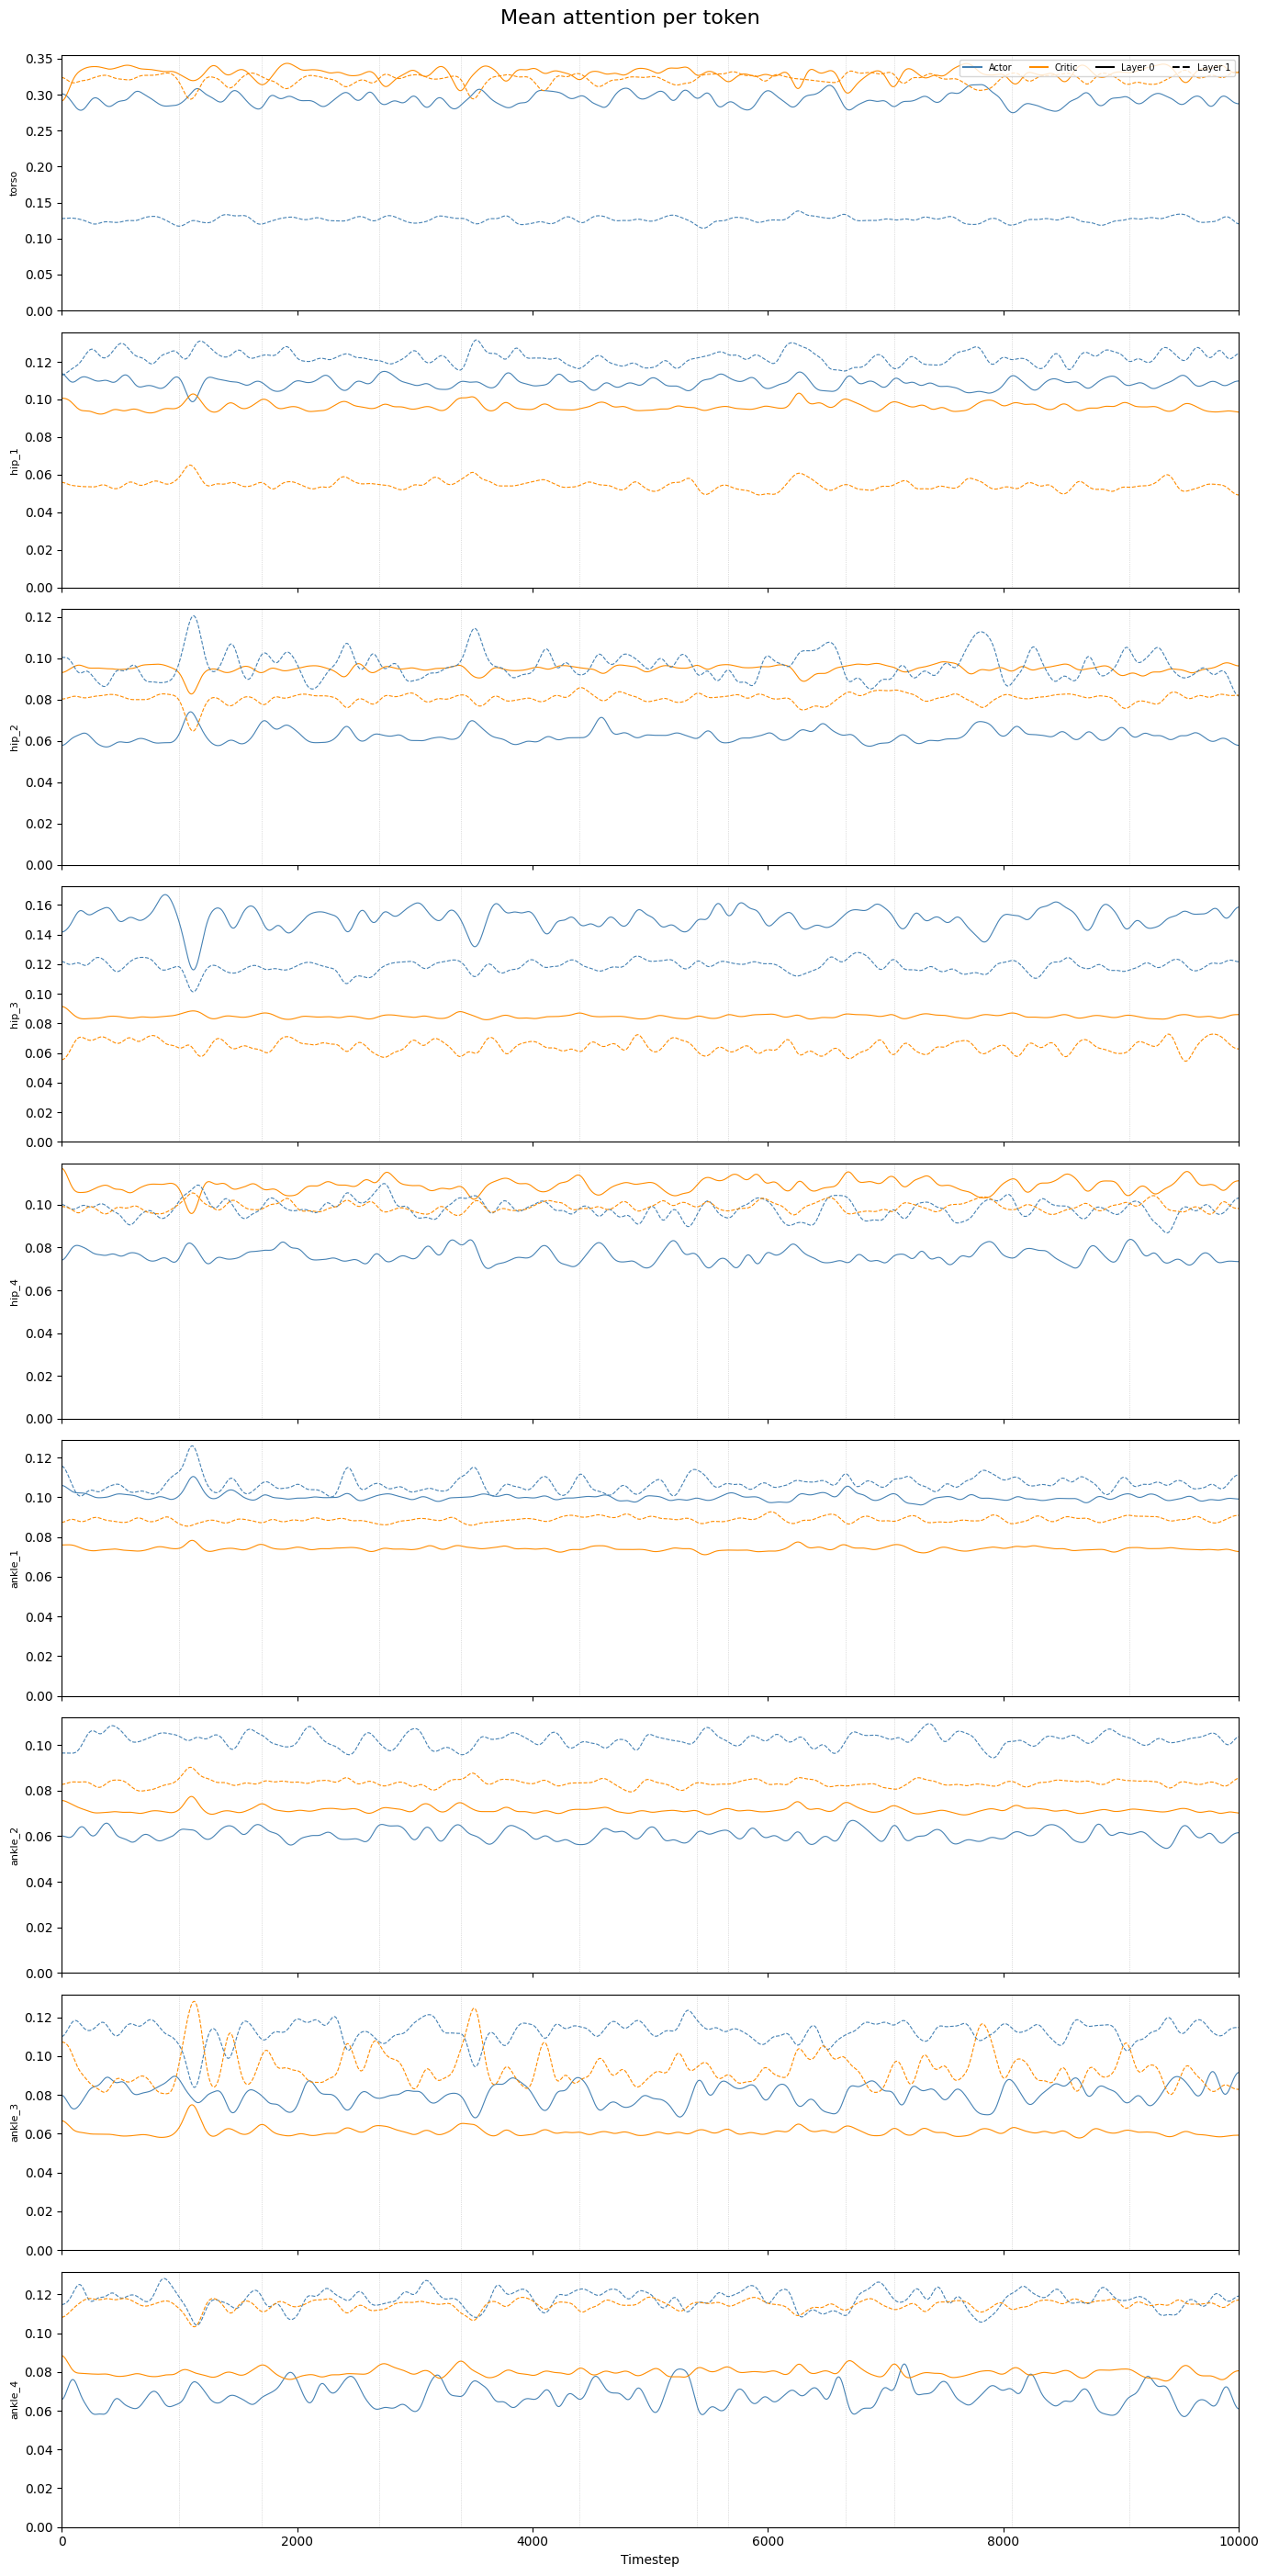

In [108]:
ACTOR_COLOR  = "steelblue"
CRITIC_COLOR = "darkorange"

fig, axes = plt.subplots(9, 1, figsize=(14, 28), sharex=True)

for j, ax in enumerate(axes):
    for layer in range(n_layers):
        ls = LAYER_STYLES[layer]
        for data, color, name in [
            (attn_by_layer,   ACTOR_COLOR,  "actor"),
            (critic_by_layer, CRITIC_COLOR, "critic"),
        ]:
            series   = data[:MAX_TIMESTEPS, layer, :, j].mean(axis=1).astype(float)
            smoothed = gaussian_filter1d(series, sigma=SIGMA)
            ax.plot(smoothed, color=color, linestyle=ls, linewidth=0.8,
                    label=f"{name} L{layer}" if j == 0 else "_")
    for end in episode_ends[:-1]:
        ax.axvline(end, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.set_ylabel(TOKEN_NAMES[j], fontsize=8)
    ax.set_ylim(0, None)
    ax.set_xlim(0, MAX_TIMESTEPS)

actor_h  = Line2D([0],[0], color=ACTOR_COLOR,  label="Actor")
critic_h = Line2D([0],[0], color=CRITIC_COLOR, label="Critic")
l0_h = Line2D([0],[0], color="k", linestyle="-",  label="Layer 0")
l1_h = Line2D([0],[0], color="k", linestyle="--", label="Layer 1")
axes[0].legend(handles=[actor_h, critic_h, l0_h, l1_h], ncol=4, fontsize=7, loc="upper right")

axes[-1].set_xlabel("Timestep")
fig.suptitle(f"Mean attention per token", fontsize=16, y=1)
plt.tight_layout()
plt.savefig("../data/attention_over_time.png", dpi=150)
plt.show()

In [109]:
ep_starts = np.concatenate([[0], episode_ends[:-1]])

def episode_received(attn_4d):
    """attn_4d [T, layers, 9, 9] -> [E, layers, 9]: mean attention received per token per episode per layer."""
    return np.array([
        attn_4d[s:e].mean(axis=(0, 2))  # mean over time & src -> [layers, 9]
        for s, e in zip(ep_starts, episode_ends)
    ])

actor_ep  = episode_received(attn_by_layer)   # [E, n_layers, 9]
critic_ep = episode_received(critic_by_layer) # [E, n_layers, 9]
print(f"actor_ep={actor_ep.shape}  critic_ep={critic_ep.shape}")

actor_ep=(100, 2, 9)  critic_ep=(100, 2, 9)


/tmp/ipykernel_1901925/3086687777.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1901925/3086687777.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1901925/3086687777.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1901925/3086687777.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxp

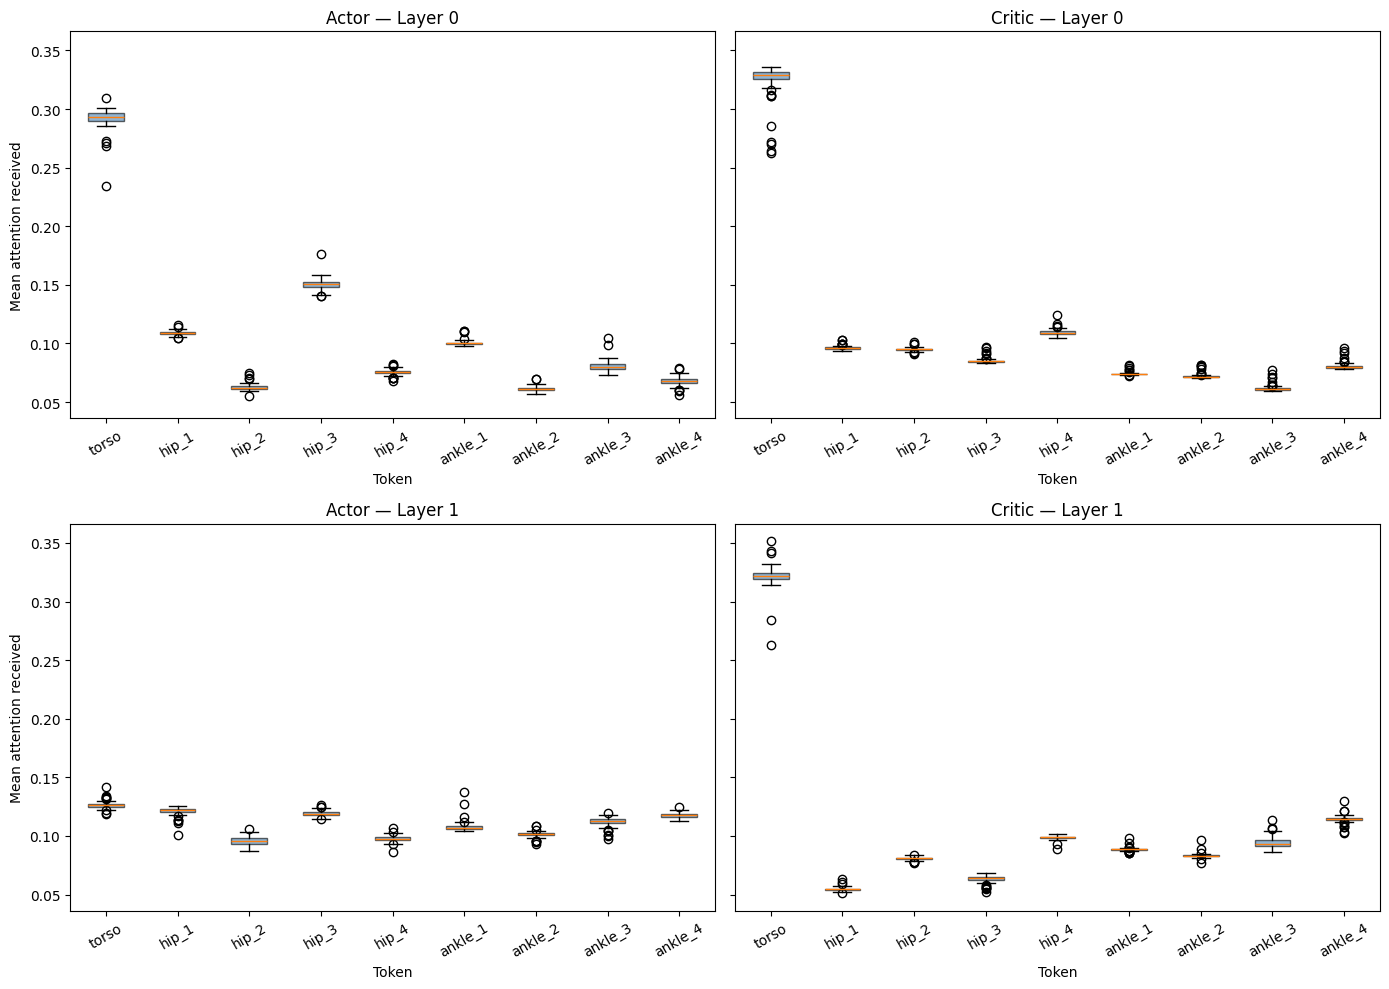

In [110]:
fig, axes = plt.subplots(n_layers, 2, figsize=(14, 5 * n_layers), sharey=True)

for row, layer in enumerate(range(n_layers)):
    for col, (data, title) in enumerate([(actor_ep, "Actor"), (critic_ep, "Critic")]):
        if n_layers == 1:
             ax = axes[col]
        else:
            ax = axes[row, col]
        ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_title(f"{title} — Layer {layer}")
        ax.set_xlabel("Token")
        ax.tick_params(axis="x", rotation=30)
        if col == 0:
            ax.set_ylabel("Mean attention received")

plt.tight_layout()
plt.savefig("../data/attention_boxplot.png", dpi=150)
plt.show()

/tmp/ipykernel_1901925/1642790093.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1901925/1642790093.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1901925/1642790093.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1901925/1642790093.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support f

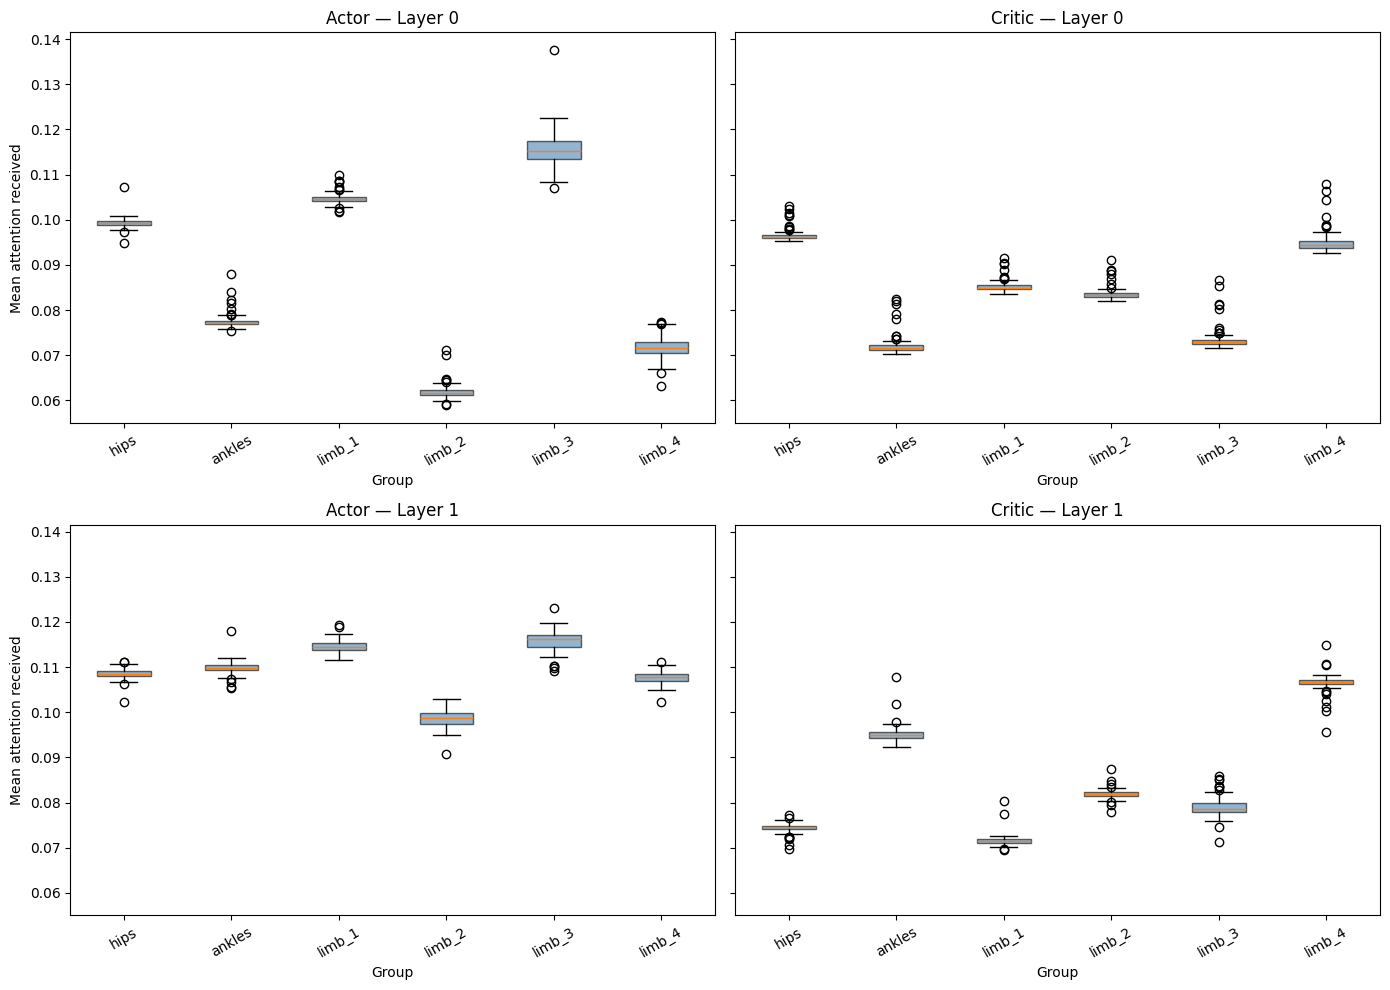

In [111]:
GROUP_NAMES = ["hips", "ankles", "leg_1", "leg_2", "leg_3", "leg_4"]
GROUP_INDICES = [
    [1, 2, 3, 4],   # hips
    [5, 6, 7, 8],   # ankles
    [1, 5],          # leg_1: hip_1 + ankle_1
    [2, 6],          # leg_2
    [3, 7],          # leg_3
    [4, 8],          # leg_4
]

def group_ep(ep_data):
    """ep_data [E, layers, 9] -> [E, layers, n_groups]"""
    return np.stack([ep_data[:, :, idx].mean(axis=-1) for idx in GROUP_INDICES], axis=-1)

actor_grp  = group_ep(actor_ep)   # [E, n_layers, 6]
critic_grp = group_ep(critic_ep)  # [E, n_layers, 6]

fig, axes = plt.subplots(n_layers, 2, figsize=(14, 5 * n_layers), sharey=True)

for row, layer in enumerate(range(n_layers)):
    for col, (data, title) in enumerate([(actor_grp, "Actor"), (critic_grp, "Critic")]):
        ax = axes[col] if n_layers == 1 else axes[row, col]
        ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
                   labels=GROUP_NAMES, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_title(f"{title} — Layer {layer}")
        ax.set_xlabel("Group")
        ax.tick_params(axis="x", rotation=30)
        if col == 0:
            ax.set_ylabel("Mean attention received")

plt.tight_layout()
plt.savefig("../data/attention_boxplot_grouped.png", dpi=150)
plt.show()

In [112]:
def draw_heatmap_figure(corr_actor, corr_critic, n_layers, names, title, fname):
    """n_layers×2 grid of N×N correlation heatmaps with row/col mean strips."""
    N = len(names)
    avg = (N + 1) / 2
    t   = 0.15 * avg   # tight gap (main → strip)
    L   = 0.65 * avg   # large gap (strip → next block)

    # Row layout per layer: [main(N), tight(t), strip(1)]  +  [large(L)] between layers
    row_ratios = []
    for i in range(n_layers):
        row_ratios += [N, t, 1]
        if i < n_layers - 1:
            row_ratios.append(L)

    # Col layout: [main(N), tight(t), strip(1), large(L), main(N), tight(t), strip(1), tight(t), cbar(0.3)]
    #              actor block                             critic block                  cbar gap
    col_ratios = [N, t, 1, L, N, t, 1, t, 0.3]
    C_CBAR = 8  # colorbar column index

    fig = plt.figure(figsize=(14, 5 * n_layers))
    gs = gridspec.GridSpec(
        len(row_ratios), len(col_ratios),
        height_ratios=row_ratios,
        width_ratios=col_ratios,
        hspace=0, wspace=0,
        figure=fig,
    )

    for layer in range(n_layers):
        r_main  = layer * 4
        r_strip = layer * 4 + 2
        last_im = None
        for c_off, (corr, net) in enumerate([(corr_actor, "Actor"), (corr_critic, "Critic")]):
            c_main  = c_off * 4      # actor: 0, critic: 4
            c_strip = c_off * 4 + 2  # actor: 2, critic: 6

            mat = corr[layer]
            row_means = mat.mean(axis=1, keepdims=True)   # [N, 1]
            col_means = mat.mean(axis=0, keepdims=True)   # [1, N]

            ax_m = fig.add_subplot(gs[r_main, c_main])
            last_im = ax_m.imshow(mat, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
            ax_m.set_title(f"{net} — Layer {layer}", fontsize=9)
            if c_off == 0:
                ax_m.set_ylabel("Query", fontsize=8)

            ax_r = fig.add_subplot(gs[r_main, c_strip], sharey=ax_m)
            ax_r.imshow(row_means, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
            ax_r.set_xticks([0]); ax_r.set_xticklabels(["mean"], fontsize=6)
            ax_r.tick_params(labelleft=False, left=False)

            ax_b = fig.add_subplot(gs[r_strip, c_main], sharex=ax_m)
            ax_b.imshow(col_means, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
            ax_b.set_yticks([0]); ax_b.set_yticklabels(["mean"], fontsize=6)
            if c_off == 0:
                ax_b.set_xlabel("Key", fontsize=8)

            # Set shared ticks; tick_params hides labels on main only
            ax_b.set_xticks(range(N))
            ax_b.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
            ax_m.tick_params(labelbottom=False)
            ax_m.set_yticks(range(N))
            ax_m.set_yticklabels(names, fontsize=7)
            ax_r.tick_params(labelleft=False, left=False)

            fig.add_subplot(gs[r_strip, c_strip]).axis("off")

        # One colorbar per layer row
        cax = fig.add_subplot(gs[r_main, C_CBAR])
        fig.colorbar(last_im, cax=cax)
        fig.add_subplot(gs[r_strip, C_CBAR]).axis("off")

    fig.suptitle(title, fontsize=12, y=0.96)
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


def group_corr(attn_nd, rew, group_indices, n_layers):
    """Group-level Pearson r by averaging raw attention within group pairs first.

    attn_nd: [N, n_layers, 9, 9]  (N = episodes or timesteps)
    rew:     [N]
    Returns: [n_layers, G, G]
    """
    G = len(group_indices)
    out = np.zeros((n_layers, G, G))
    r = rew - rew.mean(); r /= r.std() + 1e-8
    for g1, idx1 in enumerate(group_indices):
        for g2, idx2 in enumerate(group_indices):
            sub = attn_nd[:, :, idx1, :][:, :, :, idx2].mean(axis=(-2, -1))  # [N, n_layers]
            c = sub - sub.mean(axis=0, keepdims=True)
            c /= c.std(axis=0, keepdims=True) + 1e-8
            out[:, g1, g2] = (r[:, np.newaxis] * c).mean(axis=0)
    return np.abs(out)

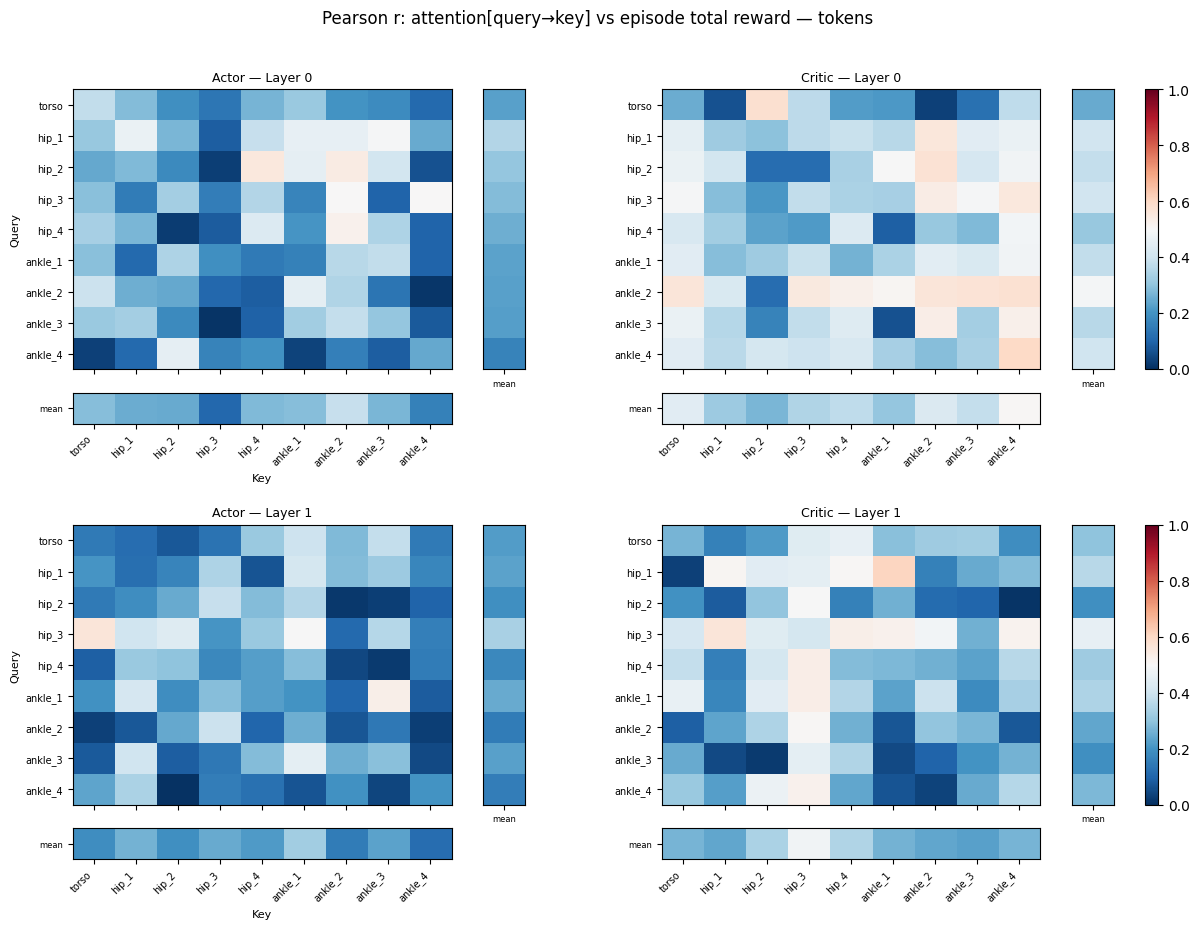

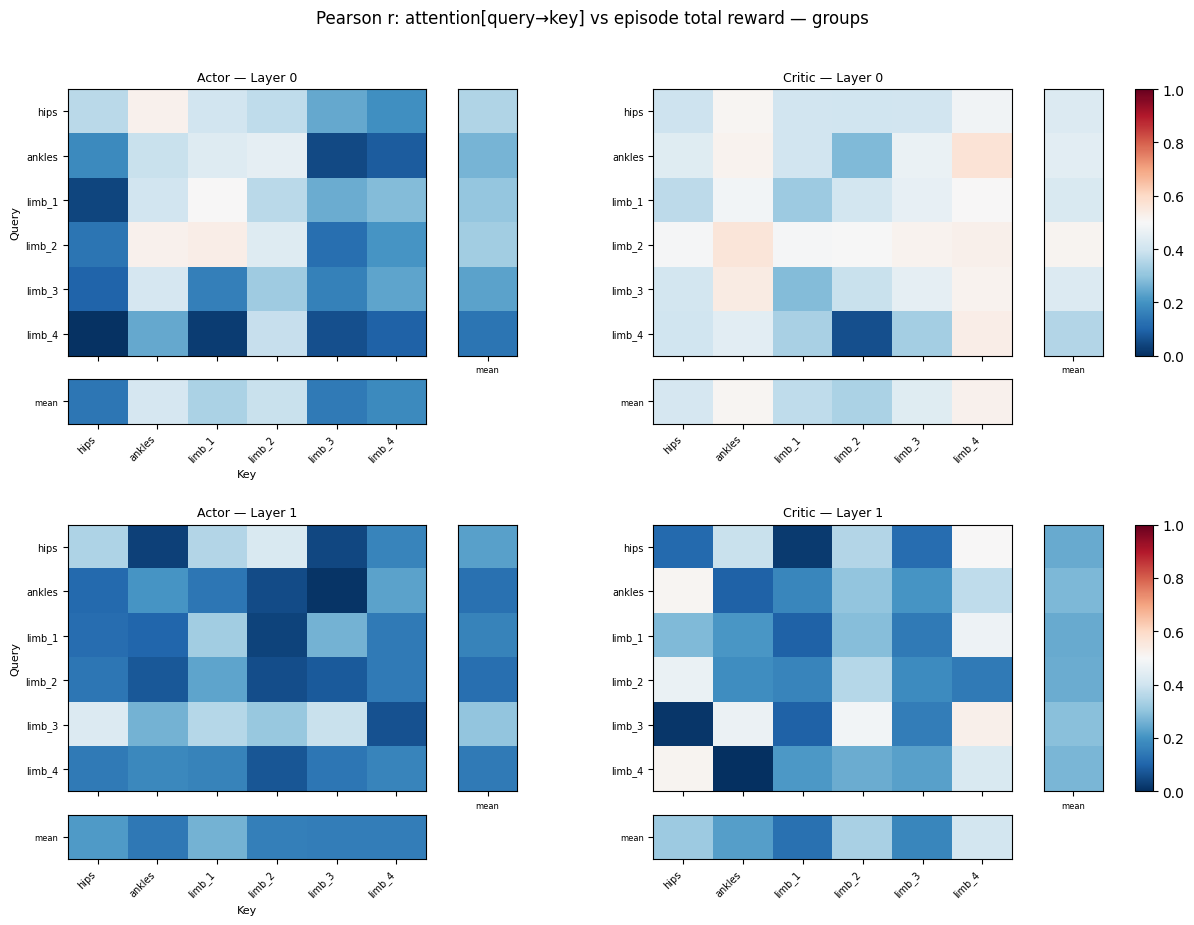

In [113]:
ep_rewards = np.array([rewards[s:e].sum() for s, e in zip(ep_starts, episode_ends)])  # [E]

ep_actor_mat  = np.array([actor_attn[s:e].mean(axis=(0,2))  for s, e in zip(ep_starts, episode_ends)])
ep_critic_mat = np.array([critic_attn[s:e].mean(axis=(0,2)) for s, e in zip(ep_starts, episode_ends)])

ep_actor_mat = np.abs(ep_actor_mat)
ep_critic_mat = np.abs(ep_critic_mat)

def vec_corr(mat, rew):
    """mat [N, n_layers, 9, 9], rew [N] → [n_layers, 9, 9] Pearson r."""
    r = rew - rew.mean(); r /= r.std() + 1e-8
    c = mat - mat.mean(axis=0, keepdims=True)
    c /= c.std(axis=0, keepdims=True) + 1e-8
    return np.abs(np.tensordot(r, c, axes=([0],[0])) / len(rew))

ep_corr_actor  = vec_corr(ep_actor_mat,  ep_rewards)
ep_corr_critic = vec_corr(ep_critic_mat, ep_rewards)

draw_heatmap_figure(
    ep_corr_actor, ep_corr_critic, n_layers, TOKEN_NAMES,
    "Pearson r: attention[query→key] vs episode total reward — tokens",
    "../data/heatmap_corr_episode_tokens.png",
)

ep_group_corr_actor  = group_corr(ep_actor_mat,  ep_rewards, GROUP_INDICES, n_layers)
ep_group_corr_critic = group_corr(ep_critic_mat, ep_rewards, GROUP_INDICES, n_layers)

draw_heatmap_figure(
    ep_group_corr_actor, ep_group_corr_critic, n_layers, GROUP_NAMES,
    "Pearson r: attention[query→key] vs episode total reward — groups",
    "../data/heatmap_corr_episode_groups.png",
)

In [ ]:
def vec_corr_step(attn_4d, rew):
    """attn_4d [T, n_layers, 9, 9], rew [T] → [n_layers, 9, 9] Pearson r."""
    r = rew - rew.mean(); r /= r.std() + 1e-8
    c = attn_4d - attn_4d.mean(axis=0, keepdims=True)
    c /= c.std(axis=0, keepdims=True) + 1e-8
    return np.abs(np.tensordot(r, c, axes=([0],[0])) / len(rew))

step_corr_actor  = vec_corr_step(attn_by_layer,   rewards)
step_corr_critic = vec_corr_step(critic_by_layer, rewards)

draw_heatmap_figure(
    step_corr_actor, step_corr_critic, n_layers, TOKEN_NAMES,
    "Pearson r: attention[query→key] vs per-step reward — tokens",
    "../data/heatmap_corr_step_tokens.png",
)

step_group_corr_actor  = group_corr(attn_by_layer,   rewards, GROUP_INDICES, n_layers)
step_group_corr_critic = group_corr(critic_by_layer, rewards, GROUP_INDICES, n_layers)

draw_heatmap_figure(
    step_group_corr_actor, step_group_corr_critic, n_layers, GROUP_NAMES,
    "Pearson r: attention[query→key] vs per-step reward — groups",
    "../data/heatmap_corr_step_groups.png",
)